Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.3
    ),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  34


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  8


### Using Model Architecture:
* 3 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [7]:
model.add(
    # First Layer
    nn.Conv2d(3, 12, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(12),
    nn.MaxPool2d(2, 2),

    # Second Layer
    nn.Conv2d(12, 24, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(24),
    nn.MaxPool2d(2, 2),

    # Third Layer
    nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(48),
    nn.MaxPool2d(2, 2),

    # Flatten
    nn.Flatten(),

    # Fully connected layer (for 64x64 input)
    nn.Linear(48 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

Architecture(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU()
      (10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Flatten(start_dim=1, end_dim=-1)
      (13): Linear(in_features=3072, out_featu

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment1/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.4208 | Val Loss: 0.7333 | Train Acc: 0.8242 | Val Acc: 0.7810 | Train F1: 0.8249 | Val F1: 0.7830
Epoch [20/100] | Train Loss: 0.2606 | Val Loss: 0.7711 | Train Acc: 0.9093 | Val Acc: 0.8097 | Train F1: 0.9095 | Val F1: 0.8098
Epoch [30/100] | Train Loss: 0.3673 | Val Loss: 1.3278 | Train Acc: 0.8582 | Val Acc: 0.6593 | Train F1: 0.8587 | Val F1: 0.6418
Epoch [40/100] | Train Loss: 0.2341 | Val Loss: 1.8985 | Train Acc: 0.9197 | Val Acc: 0.5841 | Train F1: 0.9204 | Val F1: 0.5555
Epoch [50/100] | Train Loss: 0.0641 | Val Loss: 0.7006 | Train Acc: 0.9853 | Val Acc: 0.8296 | Train F1: 0.9853 | Val F1: 0.8302
Epoch [60/100] | Train Loss: 0.0574 | Val Loss: 1.1395 | Train Acc: 0.9839 | Val Acc: 0.7699 | Train F1: 0.9841 | Val F1: 0.7662
Epoch [70/100] | Train Loss: 0.0903 | Val Loss: 0.7569 | Train Acc: 0.9712 | Val Acc: 0.8341 | Train F1: 0.9712 | Val F1: 0.8346
Epoch [80/100] | Train Loss: 0.0548 | Val Loss: 1.0709 | Train Acc: 0.9844 | Val Acc: 0.7765 | Tr

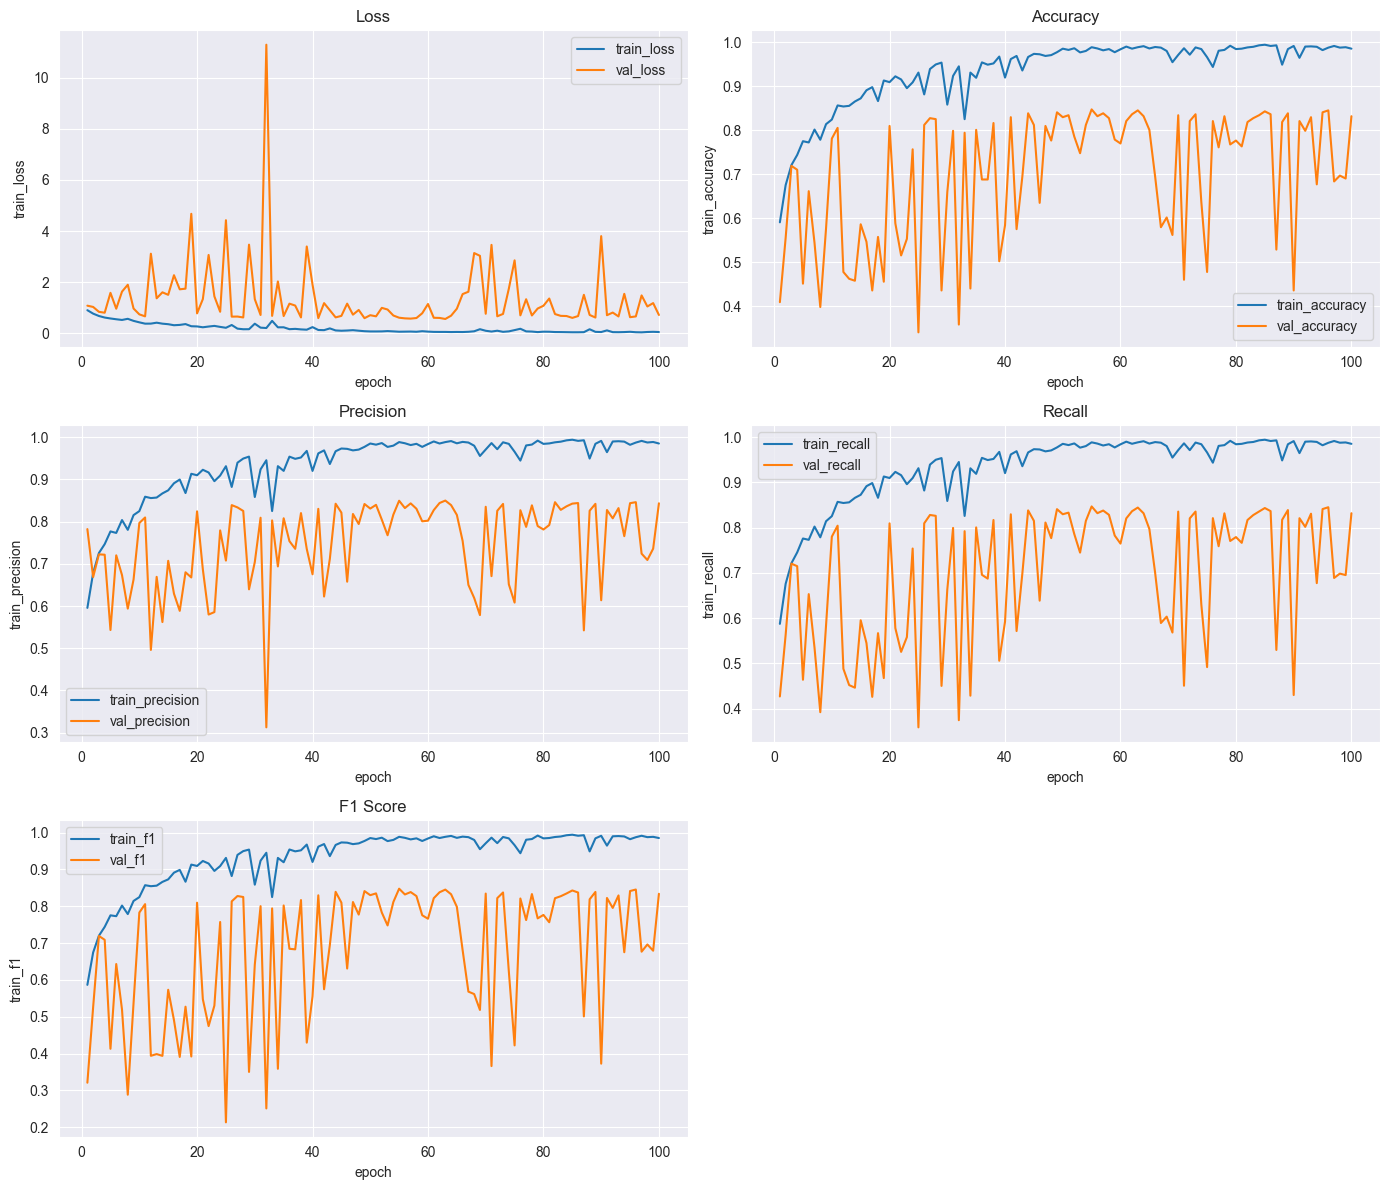

In [11]:
df = plot_training_metrics(history)

In [15]:
df

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,confusion_matrix
0,1,0.896808,1.073989,0.590737,0.595621,0.587377,0.586752,0.409292,0.782396,0.426904,0.321088,"[[tensor(142), tensor(0), tensor(0)], [tensor(155), tensor(2), tensor(0)], [tensor(112), tensor(0), tensor(41)]]"
1,2,0.761882,1.024055,0.675331,0.678504,0.675867,0.674695,0.555310,0.668669,0.563055,0.526303,"[[tensor(126), tensor(15), tensor(1)], [tensor(62), tensor(91), tensor(4)], [tensor(92), tensor(27), tensor(34)]]"
2,3,0.669534,0.832922,0.720699,0.725705,0.721360,0.720105,0.719027,0.722523,0.720464,0.719427,"[[tensor(110), tensor(20), tensor(12)], [tensor(29), tensor(111), tensor(17)], [tensor(21), tensor(28), tensor(104)]]"
3,4,0.608486,0.797963,0.743856,0.746747,0.745339,0.744136,0.710177,0.721670,0.714832,0.709021,"[[tensor(123), tensor(13), tensor(6)], [tensor(43), tensor(95), tensor(19)], [tensor(26), tensor(24), tensor(103)]]"
4,5,0.572278,1.576922,0.775047,0.776878,0.776051,0.775454,0.451327,0.543168,0.463831,0.413173,"[[tensor(130), tensor(3), tensor(9)], [tensor(77), tensor(46), tensor(34)], [tensor(119), tensor(6), tensor(28)]]"
5,6,0.541327,0.954979,0.772212,0.773344,0.773129,0.773170,0.661504,0.720245,0.653094,0.643240,"[[tensor(55), tensor(37), tensor(50)], [tensor(4), tensor(137), tensor(16)], [tensor(1), tensor(45), tensor(107)]]"
6,7,0.514514,1.625115,0.801512,0.803840,0.802397,0.801995,0.544248,0.673237,0.534985,0.519614,"[[tensor(41), tensor(90), tensor(11)], [tensor(9), tensor(142), tensor(6)], [tensor(2), tensor(88), tensor(63)]]"
7,8,0.559009,1.893785,0.778355,0.780645,0.778671,0.778918,0.398230,0.593800,0.392117,0.288488,"[[tensor(7), tensor(1), tensor(134)], [tensor(6), tensor(22), tensor(129)], [tensor(1), tensor(1), tensor(151)]]"
8,9,0.478275,0.961577,0.813800,0.815556,0.814234,0.814563,0.577434,0.662870,0.584459,0.537578,"[[tensor(104), tensor(2), tensor(36)], [tensor(60), tensor(31), tensor(66)], [tensor(25), tensor(2), tensor(126)]]"
9,10,0.420803,0.733330,0.824197,0.824993,0.825407,0.824854,0.780973,0.796830,0.780134,0.782970,"[[tensor(110), tensor(20), tensor(12)], [tensor(10), tensor(135), tensor(12)], [tensor(5), tensor(40), tensor(108)]]"


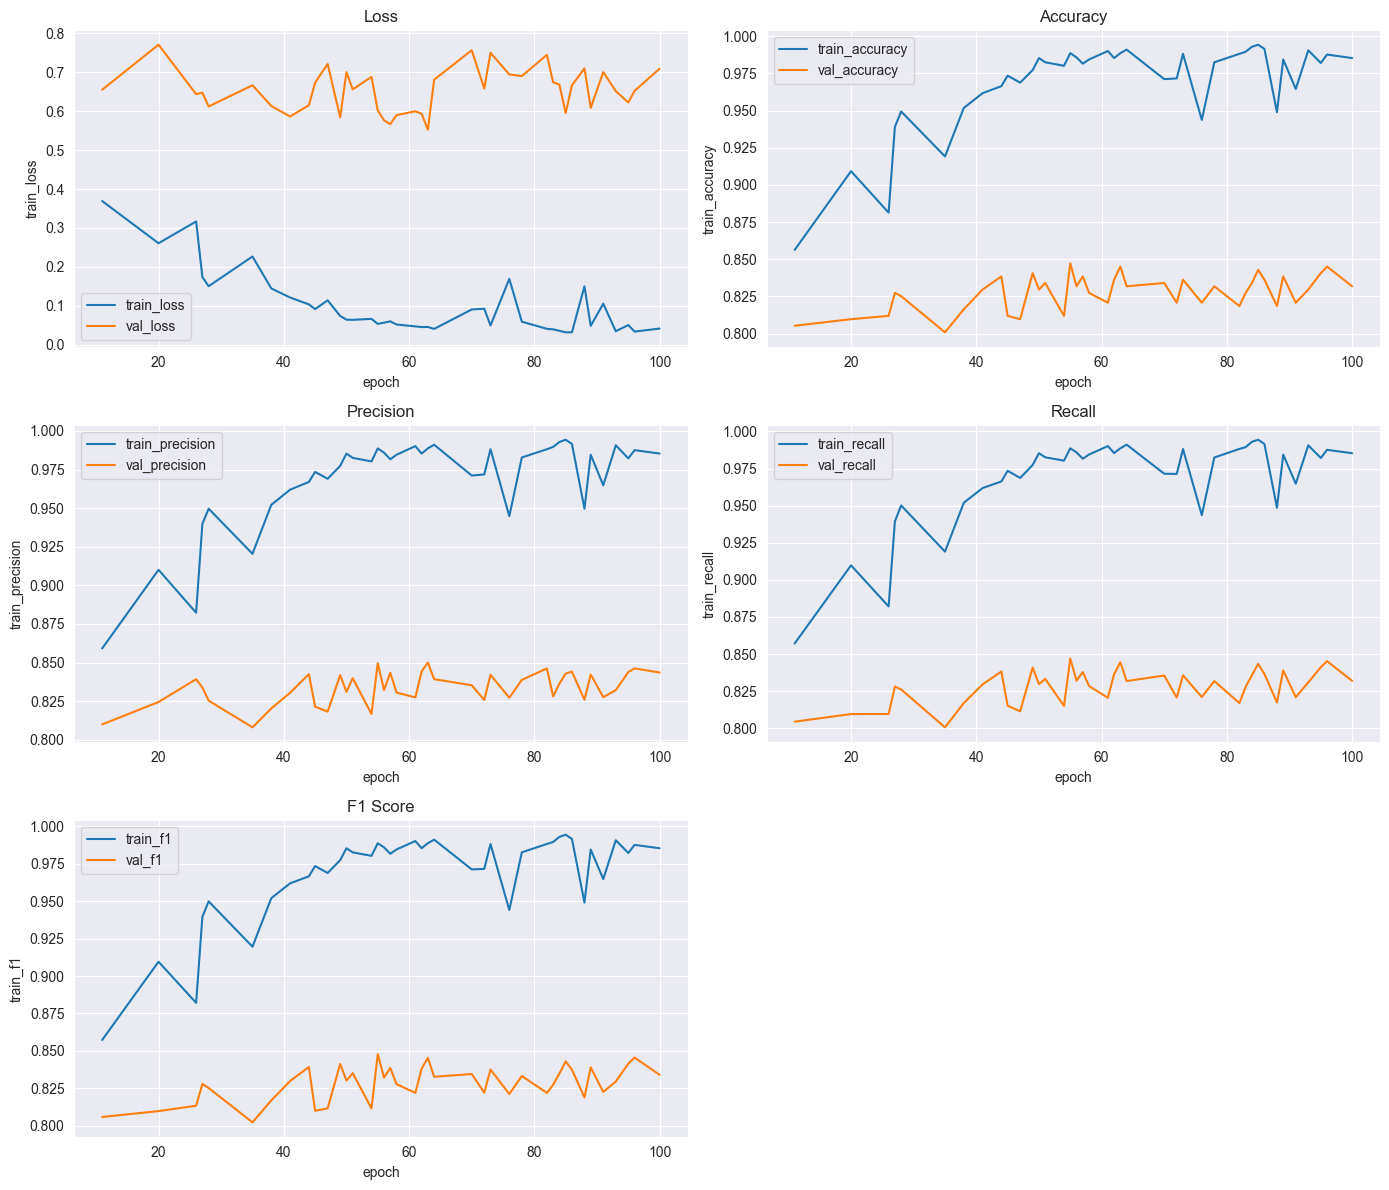

In [12]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Training/Validation Trend (100 epochs)
The model shows strong learning progress in the early epochs, with training loss continuously decreasing and training metrics improving. However, validation performance is not fully stable, showing noticeable fluctuations in validation loss and metrics. Several sharp drops in validation performance indicate possible overfitting or sensitivity to the validation samples, especially in later epochs. The best generalization performance occurs around the middle of training rather than at the final epoch.

<b>Epoch 55</b>

<b>Loss</b>
* Train Loss = 0.053326
* Valid Loss = 0.602134

<b>Training Metrics</b>
* Train Accuracy = 0.988658
* Train Precison = 0.988686
* Train Recall = 0.988616
* Train F1 = 0.988649

<b>Validation Accuracy</b>
* Validation Accuracy = 0.847345
* Validation Precision = 0.849622
* Validation Recall = 0.846955
* Validation F1 = 0.847797

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment1/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


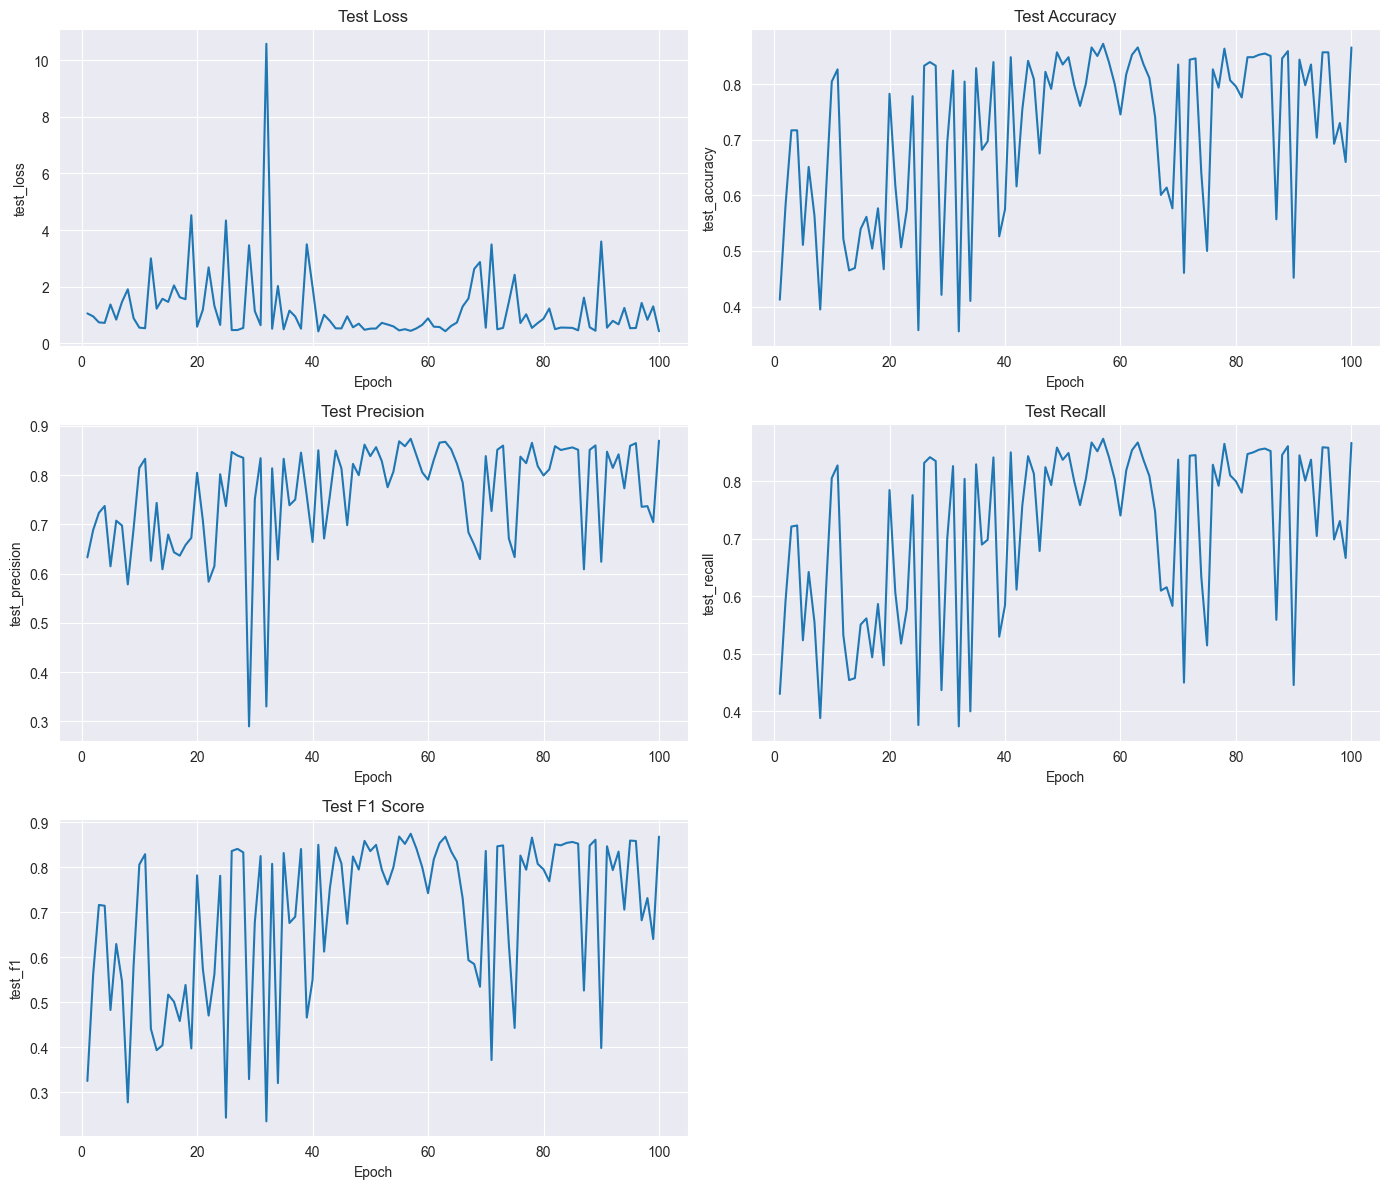

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)

In [16]:
test_metrics_df

,epoch,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,1.054110,0.412281,0.633008,0.429845,0.324753
1,2,0.950780,0.583333,0.688475,0.593075,0.560977
2,3,0.737870,0.717105,0.723510,0.721340,0.715838
3,4,0.720198,0.717105,0.737413,0.723267,0.714091
4,5,1.368762,0.510965,0.614844,0.523390,0.482431
5,6,0.835801,0.651316,0.707530,0.642238,0.629027
6,7,1.462686,0.563596,0.697596,0.555150,0.545758
7,8,1.906286,0.394737,0.578124,0.387846,0.277074
8,9,0.887395,0.605263,0.690752,0.610881,0.580248
9,10,0.551924,0.804825,0.814709,0.805850,0.805544


### Test Performance Trend (100 epochs)
The test results show rapid improvement during the early training phase, with accuracy and F1-score increasing significantly within the first 30 epochs. After this point, the model maintains a strong performance range but shows noticeable fluctuations, including sudden drops in some epochs. These sharp variations suggest instability during evaluation, but the overall trend remains positive. The highest and most consistent test performance is achieved in the later training phase.

<b>Epoch 57</b>

* Loss = 0.438216
* Accuracy = 0.872807
* Precision = 0.873970
* Recall = 0.874264
* F1-Score = 0.874110